# Cross-Domain Concept Diffusion

A concept first appears in one domain (e.g. `attention` in MT), then later shows up in other domains (QA, SA, SUM, DIA). This notebook measures and visualises that diffusion pattern.

**Inputs (no retraining needed):**
- `knowledge_edges.csv` — (source_paper, entity, predicate, year)
- `entity_nodes.csv` — entity ID → name
- `paper_nodes.csv` — paper ID → domain

**Outputs:**
- `cross_domain_diffusion.csv` — per-entity first appearance year per domain
- `top_diffusing_concepts.csv` — top 20 concepts by number of domains reached
- `diffusion_lag.csv` — average lag (years) between origin domain and each target domain
- `diffusion_heatmap.png`
- `diffusion_timeline.png`
- `diffusion_lag_bar.png`

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

## 0. Configuration

In [34]:
# Paths
BASE          = '../../outputs/final'          # adjust if needed
EDGES_PATH    = f'{BASE}/knowledge_edges.csv'
ENTITY_PATH   = f'{BASE}/entity_nodes.csv'
PAPERS_PATH   = f'{BASE}/paper_nodes.csv'
OUT_DIR       = f'{BASE}'                      # save outputs alongside other CSVs

# Domains to include (exclude NLI and PAR — no NOVEL papers)
MAIN_DOMAINS  = ['MT', 'SA', 'QA', 'DIA', 'SUM']

print('Paths configured.')

Paths configured.


## 1. Load Data

In [35]:
edges   = pd.read_csv(EDGES_PATH)
entities = pd.read_csv(ENTITY_PATH)
papers  = pd.read_csv(PAPERS_PATH)

print(f'Knowledge edges : {len(edges):,}')
print(f'Entity nodes    : {len(entities):,}')
print(f'Paper nodes     : {len(papers):,}')
print(f'Domains         : {sorted(papers["domain"].dropna().unique())}')

Knowledge edges : 577,024
Entity nodes    : 293,149
Paper nodes     : 4,860
Domains         : ['DIA', 'MT', 'NLI', 'PAR', 'QA', 'SA', 'SUM']


## 2. Build Entity–Domain–Year Table

For each edge (paper → entity), attach the paper's domain.
Then compute the **first year** each entity appeared in each domain.

In [36]:
# Attach domain from paper_nodes to each edge (via source paper ID)
edge_domain = edges[['source', 'target', 'year']].merge(
    papers[['node_id', 'domain']],
    left_on='source', right_on='node_id',
    how='left'
).drop(columns='node_id')

# Keep only main domains and valid years
edge_domain = edge_domain[
    edge_domain['domain'].isin(MAIN_DOMAINS) &
    edge_domain['year'].notna()
]

# FILTER 1: Name quality and degree filters handle noise
# 2022+ data uses a different extraction pipeline (OpenAlex-based) which is noisier.
# The degree >= 15 and name quality filters below are sufficient
# to remove fragments and low-frequency noise across all years.
edge_clean = edge_domain.copy()
print(f'Edges (all years, main domains): {len(edge_clean):,}')

# FILTER 2: High-degree entities only
# Require each entity to appear in at least MIN_DEGREE distinct papers.
# Low-frequency entities are likely noise.
MIN_DEGREE = 15
degree = (
    edge_clean.groupby('target')['source']
    .nunique()
    .reset_index()
    .rename(columns={'source': 'degree'})
)
high_degree_ids = degree[degree['degree'] >= MIN_DEGREE]['target']
print(f'Entities with degree >= {MIN_DEGREE}: {len(high_degree_ids):,}')

# FILTER 3: Name quality
# Exclude generic/uninformative names and sentence fragments.
import re

GENERIC_NAMES = {
    'results','model','models','performance','baseline','baselines','training',
    'better','best','accuracy','improvement','improvements','outperforms','outperform',
    'words','best performance','better performance','our model','ablation analysis',
    'hyperparameters','experimental setup','method','methods','higher','lower','well',
    'scores','score','similarly','comparable results','proposed model','both datasets',
    'sentence pairs','both tasks','most cases','layers','predictions','entities',
    'proposed approach','significantly improves','significantly improved','performance gain',
    'inference','document','sequence','reward','vocabulary size','seq2seq','regularization',
    'comparable','significantly','notably','recently','however','although','overall',
    'previous','following','thus','hence','since','while','both','each','several',
    'various','all','most','many','some','other','our','their','its','such',
    'slightly better', 'highest performance', 'our approach', 'without', 'advantages'
    'our system', 'our systems', 'all systems', 'all tasks', 'all baselines',
    'aligning', 'unlike', 'measuring', 'problem', 'our framework', 'each model',
    'cognitive', 'advantages', 'frequency', 'distinct', 'creating', 'targeted', 'neural', 'of deep learning',
    'recognising textual entailment', 'clinical', 'fluency', 'vocabulary'
}
SINGLE_GENERIC = {
    'results','model','training','accuracy','loss','layers','words','scores','method',
    'higher','lower','better','best','well','reward','inference','document','sequence',
    'entities','baseline','models','methods','performance','decoder','encoder','bleu',
    'dropout','dimension','questions','attention','embeddings','embedding','features',
    'dataset','datasets','task','tasks','output','outputs','input','inputs','weight',
    'weights','layer','network','networks','system','systems','approach','similar',
    'different','large','small','high','low','good','new','first','last','both','each',
    'more','less','rate','norm','image','benefit','adam','relevance','generator',
    'optimizer','dimensions','pytorch','tensorflow', 'worse', 'poorly', 'beneficial', 'gain', 'full model',
    'our framework', 'novel framework', 'performances', 'test set',
    'robust', 'relevant', 'existing', 'structural', 'scaling',
    'increases', 'integrated', 'integrative', 'interactive',
    'despite', 'vision', 'climate'
}

def is_clean_name(name):
    if not isinstance(name, str): return False
    n = name.strip().lower()
    words = n.split()
    if not (1 <= len(words) <= 4): return False
    if re.search(r'[,;()]', n): return False
    if n in GENERIC_NAMES: return False
    if re.match(r'^[\-\[\]0-9\"\'\(]', n): return False
    if words[-1] in {'the','a','an','of','in','for','to','and','or','with','from','by','as','is','are'}: return False
    if words[0] in {'the','a','an'}: return False
    if len(n) < 4: return False
    if len(words) == 1 and n in SINGLE_GENERIC: return False
    if len(words) == 1 and len(n) < 6: return False     ## This catches single short words like "despite", "is", "s" etc.
    return True

entities_clean = entities[
    entities['node_id'].isin(high_degree_ids) &
    entities['name'].apply(is_clean_name)
].copy()
print(f'Entities after name quality filter: {len(entities_clean):,}')

# Apply entity filter to edges
edge_filtered = edge_clean[edge_clean['target'].isin(entities_clean['node_id'])]

# First appearance of each entity in each domain
first_appearance = (
    edge_filtered.groupby(['target', 'domain'])['year']
    .min()
    .reset_index()
    .rename(columns={'target': 'entity_id', 'year': 'first_year'})
)
first_appearance = first_appearance.merge(
    entities[['node_id', 'name']],
    left_on='entity_id', right_on='node_id',
    how='left'
).drop(columns='node_id')

print(f'Entity-domain first appearance rows: {len(first_appearance):,}')
print(f'Unique entities tracked: {first_appearance["entity_id"].nunique():,}')


Edges (all years, main domains): 477,536
Entities with degree >= 15: 1,408
Entities after name quality filter: 860
Entity-domain first appearance rows: 3,810
Unique entities tracked: 860


## 3. Identify Cross-Domain Concepts

A concept **diffuses** if it appears in 2 or more domains.
The **origin domain** is the domain where it first appeared.

In [37]:
# Count how many domains each entity appears in
domain_count = (
    first_appearance.groupby('entity_id')['domain']
    .nunique()
    .reset_index()
    .rename(columns={'domain': 'n_domains'})
)

# Keep only multi-domain entities
multi_domain_ids = domain_count[domain_count['n_domains'] >= 2]['entity_id']
multi = first_appearance[first_appearance['entity_id'].isin(multi_domain_ids)].copy()

print(f'Entities appearing in 2+ domains : {len(multi_domain_ids):,}')
print(f'Entities appearing in 3+ domains : {(domain_count["n_domains"] >= 3).sum():,}')
print(f'Entities appearing in 4+ domains : {(domain_count["n_domains"] >= 4).sum():,}')
print(f'Entities appearing in all 5 domains: {(domain_count["n_domains"] == 5).sum():,}')

# Assign origin domain = domain with earliest first_year
origin = (
    multi.sort_values('first_year')
    .groupby('entity_id')
    .first()
    .reset_index()
    .rename(columns={'domain': 'origin_domain', 'first_year': 'origin_year'})[['entity_id', 'origin_domain', 'origin_year']]
)

multi = multi.merge(origin, on='entity_id', how='left')
print(f'\nOrigin domain distribution:')
print(multi.drop_duplicates('entity_id')['origin_domain'].value_counts().to_string())

Entities appearing in 2+ domains : 834
Entities appearing in 3+ domains : 802
Entities appearing in 4+ domains : 748
Entities appearing in all 5 domains: 566

Origin domain distribution:
origin_domain
MT     375
DIA    156
SA     154
QA      78
SUM     71


## 4. Top Diffusing Concepts

In [38]:
# Top concepts by domains reached
top_diffusing = (
    multi.merge(domain_count, on='entity_id')
    .drop_duplicates('entity_id')
    .sort_values('n_domains', ascending=False)
    [['entity_id', 'name', 'origin_domain', 'origin_year', 'n_domains']]
    .head(20)
    .reset_index(drop=True)
)

print('Top 20 Most Diffusing Concepts:')
print(top_diffusing.to_string(index=False))

top_diffusing.to_csv(f'{OUT_DIR}/top_diffusing_concepts.csv', index=False)
print('\nSaved top_diffusing_concepts.csv')

Top 20 Most Diffusing Concepts:
   entity_id                 name origin_domain  origin_year  n_domains
E_02bd92faa3               author            QA       2018.0          5
E_fe347b8749             fasttext            MT       2018.0          5
E_03c88dfb2e           full model            MT       2011.0          5
E_05199deca1               impact            QA       2012.0          5
E_f54f5d2e0e         unsupervised            MT       2012.0          5
E_f4af8b5789               policy           DIA       2017.0          5
E_d66636b253              quality            MT       2012.0          5
E_d6c70a1379          introducing           DIA       2022.0          5
E_d6cf78db41            decreases            MT       2012.0          5
E_d6fa5adbdf           multimodal            SA       2022.0          5
E_d79019a185        higher scores            MT       2010.0          5
E_d79eb34312          beam search            MT       2010.0          5
E_d866f4a8ea             sentenc

## 5. Diffusion Lag Analysis

For each (origin → target domain) pair, compute the average number of years before the concept reaches the target domain.

In [39]:
# Compute lag = first_year_in_target - origin_year
# Only for non-origin appearances
lag_df = multi[multi['domain'] != multi['origin_domain']].copy()
lag_df['lag_years'] = lag_df['first_year'] - lag_df['origin_year']

# Average lag per origin→target pair
diffusion_lag = (
    lag_df.groupby(['origin_domain', 'domain'])['lag_years']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={'domain': 'target_domain', 'mean': 'mean_lag', 'median': 'median_lag', 'count': 'n_concepts'})
    .sort_values('mean_lag')
)

print('Diffusion Lag (years) by Origin → Target Domain:')
print(diffusion_lag.to_string(index=False))

diffusion_lag.to_csv(f'{OUT_DIR}/diffusion_lag.csv', index=False)
print('\nSaved diffusion_lag.csv')

Diffusion Lag (years) by Origin → Target Domain:
origin_domain target_domain  mean_lag  median_lag  n_concepts
          DIA            MT  0.624161         0.0         149
          DIA            QA  0.662252         0.0         151
          DIA            SA  0.775362         0.0         138
          DIA           SUM  0.914286         0.0         140
           QA            MT  2.040000         1.0          75
          SUM            MT  2.296875         2.0          64
           SA            MT  2.427586         1.0         145
           QA            SA  2.602740         2.0          73
           QA           DIA  3.277778         3.0          72
           QA           SUM  3.412698         3.0          63
          SUM            SA  3.418182         2.0          55
          SUM            QA  3.515625         3.0          64
           MT            SA  3.988406         3.0         345
          SUM           DIA  4.029851         4.0          67
           SA        

## 6. Save Full Diffusion Table

In [40]:
# Save complete first-appearance table for all multi-domain entities
cross_domain_out = (
    multi[['entity_id', 'name', 'domain', 'first_year', 'origin_domain', 'origin_year']]
    .sort_values(['entity_id', 'first_year'])
    .reset_index(drop=True)
)

cross_domain_out.to_csv(f'{OUT_DIR}/cross_domain_diffusion.csv', index=False)
print(f'Saved cross_domain_diffusion.csv  ({len(cross_domain_out):,} rows)')

Saved cross_domain_diffusion.csv  (3,784 rows)


## 7. Visualisation 1 — Diffusion Heatmap

How many concepts flow from each origin domain to each target domain.

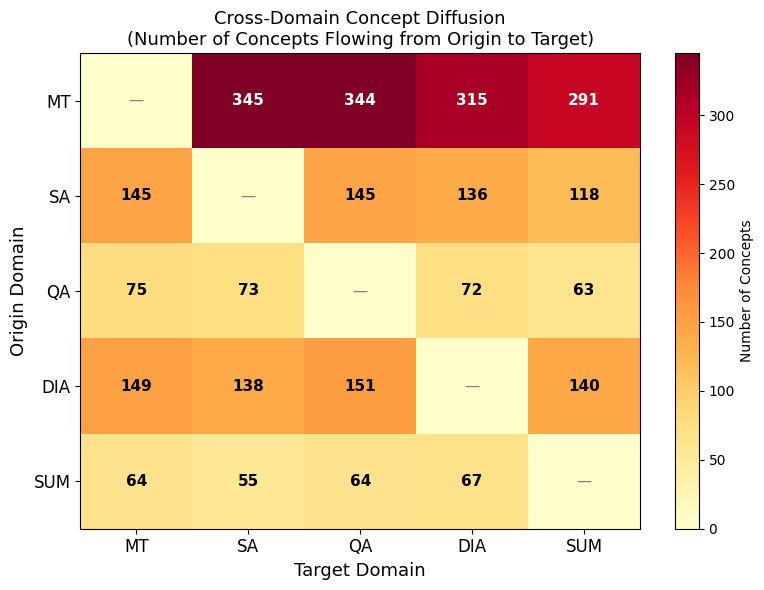

Saved diffusion_heatmap.png


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot: rows = origin, cols = target, values = n_concepts
heatmap_data = diffusion_lag.pivot(
    index='origin_domain', columns='target_domain', values='n_concepts'
).reindex(index=MAIN_DOMAINS, columns=MAIN_DOMAINS).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(MAIN_DOMAINS)))
ax.set_yticks(range(len(MAIN_DOMAINS)))
ax.set_xticklabels(MAIN_DOMAINS, fontsize=12)
ax.set_yticklabels(MAIN_DOMAINS, fontsize=12)
ax.set_xlabel('Target Domain', fontsize=13)
ax.set_ylabel('Origin Domain', fontsize=13)
ax.set_title('Cross-Domain Concept Diffusion\n(Number of Concepts Flowing from Origin to Target)', fontsize=13)

# Annotate cells
for i in range(len(MAIN_DOMAINS)):
    for j in range(len(MAIN_DOMAINS)):
        val = int(heatmap_data.values[i, j])
        text_color = 'white' if val > heatmap_data.values.max() * 0.6 else 'black'
        if i != j:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=11, fontweight='bold', color=text_color)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=11, color='grey')

plt.colorbar(im, ax=ax, label='Number of Concepts')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/diffusion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved diffusion_heatmap.png')

## 8. Visualisation 2 — Timeline of Top Diffusing Concepts

For the top 15 concepts (by domains reached), show when they first appeared in each domain.

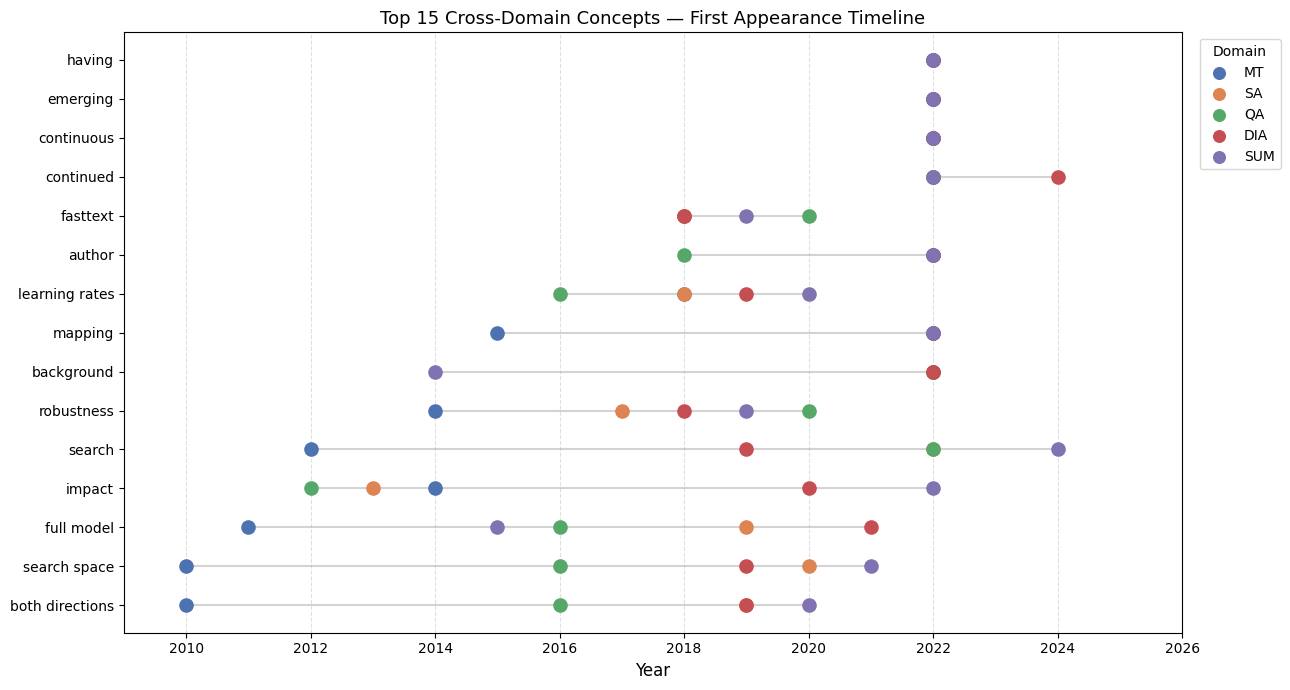

Saved diffusion_timeline.png


In [42]:
# Get top 15 by n_domains, then by earliest origin year
top15_ids = (
    domain_count.sort_values('n_domains', ascending=False)
    .head(15)['entity_id']
    .tolist()
)

top15 = first_appearance[first_appearance['entity_id'].isin(top15_ids)].copy()
top15 = top15[top15['domain'].isin(MAIN_DOMAINS)]

# Pivot for plotting
pivot = top15.pivot(index='name', columns='domain', values='first_year')
pivot = pivot.reindex(columns=MAIN_DOMAINS)

# Sort by earliest appearance
pivot['_min'] = pivot.min(axis=1)
pivot = pivot.sort_values('_min').drop(columns='_min')

# Color per domain
domain_colors = {
    'MT': '#4C72B0', 'SA': '#DD8452', 'QA': '#55A868',
    'DIA': '#C44E52', 'SUM': '#8172B2'
}

fig, ax = plt.subplots(figsize=(13, 7))

for i, (concept, row) in enumerate(pivot.iterrows()):
    years = row.dropna()
    if len(years) < 2:
        continue
    # Draw line from first to last appearance
    ax.plot([years.min(), years.max()], [i, i],
            color='lightgrey', linewidth=1.5, zorder=1)
    for domain, year in years.items():
        ax.scatter(year, i, color=domain_colors.get(domain, 'grey'),
                   s=90, zorder=2, label=domain)

ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Top 15 Cross-Domain Concepts — First Appearance Timeline', fontsize=13)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_xlim(2009, 2026)

# Legend (deduplicate)
handles = [plt.scatter([], [], color=c, s=70, label=d)
           for d, c in domain_colors.items()]
ax.legend(handles=handles, title='Domain', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/diffusion_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved diffusion_timeline.png')

## 9. Visualisation 3 — Average Diffusion Lag by Domain Pair

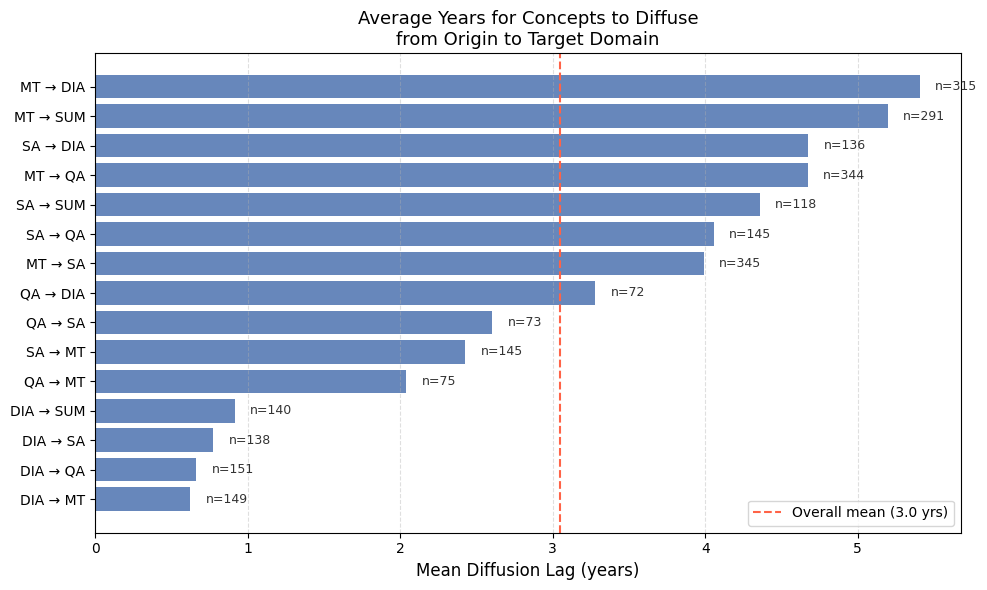

Saved diffusion_lag_bar.png


In [43]:
# Bar chart: mean lag years for each origin→target pair (top 15 pairs by concept count)
top_pairs = diffusion_lag.sort_values('n_concepts', ascending=False).head(15).copy()
top_pairs['pair'] = top_pairs['origin_domain'] + ' → ' + top_pairs['target_domain']
top_pairs = top_pairs.sort_values('mean_lag')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_pairs['pair'], top_pairs['mean_lag'],
               color='#4C72B0', alpha=0.85)

# Annotate with concept count
for bar, (_, row) in zip(bars, top_pairs.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"n={int(row['n_concepts'])}",
            va='center', fontsize=9, color='#333333')

ax.set_xlabel('Mean Diffusion Lag (years)', fontsize=12)
ax.set_title('Average Years for Concepts to Diffuse\nfrom Origin to Target Domain', fontsize=13)
ax.axvline(x=top_pairs['mean_lag'].mean(), color='tomato',
           linestyle='--', linewidth=1.5, label=f'Overall mean ({top_pairs["mean_lag"].mean():.1f} yrs)')
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/diffusion_lag_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved diffusion_lag_bar.png')

## 10. Summary

In [44]:
print('Cross-Domain Concept Diffusion Summary')
print(f'Total entities tracked               : {first_appearance["entity_id"].nunique():,}')
print(f'Entities appearing in 2+ domains     : {len(multi_domain_ids):,}')
print(f'Entities appearing in all 5 domains  : {(domain_count["n_domains"] == 5).sum():,}')
print()
print('Top 5 origin domains (most concepts exported):')
print(multi.drop_duplicates('entity_id')['origin_domain'].value_counts().head().to_string())
print()
print('Fastest diffusion pairs (lowest mean lag):')
print(diffusion_lag.sort_values('mean_lag').head(5)[['origin_domain','target_domain','mean_lag','n_concepts']].to_string(index=False))
print()
print('Slowest diffusion pairs (highest mean lag):')
print(diffusion_lag.sort_values('mean_lag', ascending=False).head(5)[['origin_domain','target_domain','mean_lag','n_concepts']].to_string(index=False))
print()
print('Outputs saved:')
print('  cross_domain_diffusion.csv')
print('  top_diffusing_concepts.csv')
print('  diffusion_lag.csv')
print('  diffusion_heatmap.png')
print('  diffusion_timeline.png')
print('  diffusion_lag_bar.png')

Cross-Domain Concept Diffusion Summary
Total entities tracked               : 860
Entities appearing in 2+ domains     : 834
Entities appearing in all 5 domains  : 566

Top 5 origin domains (most concepts exported):
origin_domain
MT     375
DIA    156
SA     154
QA      78
SUM     71

Fastest diffusion pairs (lowest mean lag):
origin_domain target_domain  mean_lag  n_concepts
          DIA            MT  0.624161         149
          DIA            QA  0.662252         151
          DIA            SA  0.775362         138
          DIA           SUM  0.914286         140
           QA            MT  2.040000          75

Slowest diffusion pairs (highest mean lag):
origin_domain target_domain  mean_lag  n_concepts
           MT           DIA  5.406349         315
           MT           SUM  5.195876         291
           SA           DIA  4.676471         136
           MT            QA  4.671512         344
           SA           SUM  4.355932         118

Outputs saved:
  cross_do